# Temperature Prediction

## Objective
Predict the **temperature** based on humidity data.


## Dataset Overview
The dataset contains hourly or daily readings of humidity and temperature.


## Workflow
1. Load the dataset  
2. Explore and clean the data  
3. Train a regression model  
4. Evaluate predictions


In [11]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [12]:
# Load the dataset
df = pd.read_csv("humidity.csv")
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701548 entries, 0 to 701547
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   sensor_id    701548 non-null  int64  
 1   lat          701548 non-null  float64
 2   lon          701548 non-null  float64
 3   pressure     701548 non-null  float64
 4   temperature  701548 non-null  float64
 5   humidity     701548 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 32.1 MB


,sensor_id,lat,lon,pressure,temperature,humidity
0,2266,42.738,23.272,95270.27,23.46,62.48
1,2292,42.663,23.273,94355.83,23.06,59.46
2,3096,42.700,23.360,95155.81,26.53,44.38
3,3428,42.624,23.406,94679.57,28.34,38.28
4,3472,42.669,23.318,94327.88,26.31,46.37


## Exploratory Data Analysis


In [13]:
# Check for missing values
missing = df.isna().sum()
print("Missing values per column:")
print(missing)

# Display summary statistics
df.describe()

Missing values per column:
sensor_id      0
lat            0
lon            0
pressure       0
temperature    0
humidity       0
dtype: int64


,sensor_id,lat,lon,pressure,temperature,humidity
count,701548.000000,701548.000000,701548.000000,701548.000000,701548.000000,701548.000000
mean,2835.419842,42.679722,23.333739,94965.292500,24.754990,48.348949
std,798.018890,0.025568,0.039365,2577.210945,14.013001,20.907247
min,1764.000000,42.622000,23.240000,0.000000,-145.120000,0.000000
25%,2224.000000,42.665000,23.310000,94528.017500,20.630000,34.140000
50%,2323.000000,42.685000,23.332000,95005.480000,24.780000,48.350000
75%,3474.000000,42.694000,23.360000,95405.132500,29.870000,62.940000
max,4661.000000,42.738000,23.419000,164926.750000,61.170000,100.000000


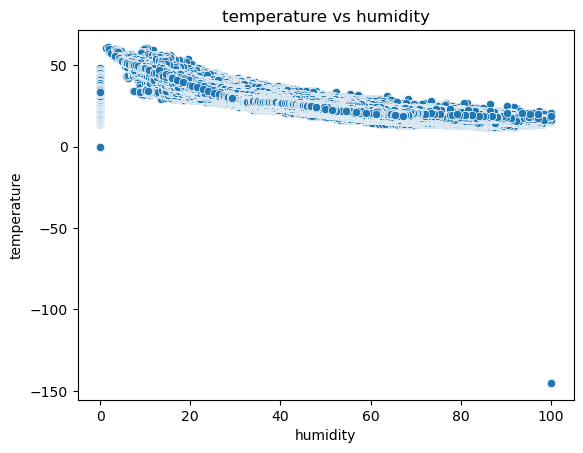

In [14]:
# Scatter plot to observe relationship
numeric_cols = df.select_dtypes(include="number").columns
humidity_col = next((c for c in numeric_cols if "humid" in c.lower()), None)
temp_col = next((c for c in numeric_cols if "temp" in c.lower()), None)

if humidity_col and temp_col:
    sns.scatterplot(data=df, x=humidity_col, y=temp_col)
    plt.title(f"{temp_col} vs {humidity_col}")
    plt.show()
else:
    print("Could not find humidity/temperature columns. Numeric columns:", list(numeric_cols))

## Data Preprocessing

In [15]:
# Drop any rows with missing values
df_clean = df.dropna().copy()

# Define features and target
numeric_cols = df_clean.select_dtypes(include="number").columns
humidity_col = next((c for c in numeric_cols if "humid" in c.lower()), None)
temp_col = next((c for c in numeric_cols if "temp" in c.lower()), None)

if not humidity_col or not temp_col:
    raise ValueError(f"Expected humidity and temperature columns. Found numeric columns: {list(numeric_cols)}")

X = df_clean[[humidity_col]]
y = df_clean[temp_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
 )

## Model Training

In [16]:
# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

## Evaluation


MSE: 144.0848
RMSE: 12.0035
R2: 0.2570


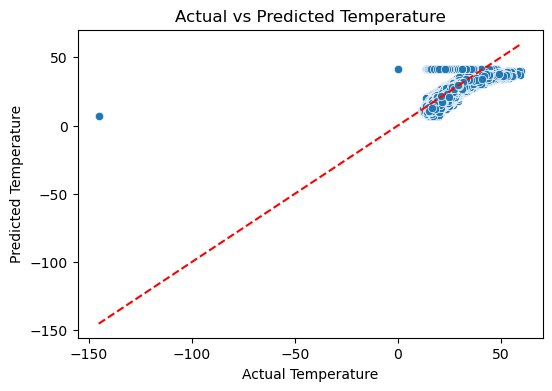

In [17]:
# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

# Plot actual vs predicted
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")
plt.show()

## Conclusion
- A simple linear regression model was used to predict temperature from humidity.  
- Consider using polynomial regression or time-series models for more complex patterns.


In [18]:
# Show model equation and sample predictions
coef = model.coef_[0] if hasattr(model, "coef_") else None
intercept = model.intercept_ if hasattr(model, "intercept_") else None
print(f"Model equation: {temp_col} = {coef:.4f} * {humidity_col} + {intercept:.4f}")

sample = pd.DataFrame({
    humidity_col: X_test.iloc[:5, 0],
    "Actual": y_test.iloc[:5],
    "Predicted": y_pred[:5]
})
sample

Model equation: temperature = -0.3412 * humidity + 41.2517


,humidity,Actual,Predicted
62175,77.12,16.58,14.936811
665219,26.92,31.45,32.066086
42104,67.50,20.69,18.219353
3339,52.04,23.22,23.494624
5706,37.92,32.99,28.312659
